## Imports

In [1]:
# Install additional depdendencies
%pip install -q lightning torchmetrics scikit-learn plotly ipywidgets pnpl

# Set up base path for dataset and related files (base_path is assumed to be set in the cells below!)
base_path = "./libribrain"
try:
    import google.colab  # This module is only available in Colab.
    in_colab = True
    base_path = "/content"  # This is the folder displayed in the Colab sidebar
except ImportError:
    in_colab = False

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pnpl.datasets import LibriBrainPhoneme, GroupedDataset
from torch.utils.data import DataLoader
import pandas as pd
import random
import torch
import numpy as np
import torch.nn as nn
import platform
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import lightning as L
import torchmetrics
from torchmetrics import F1Score
from lightning.pytorch.callbacks import Callback
from torchmetrics.functional import recall
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix, precision_recall_curve, jaccard_score
from matplotlib.colors import ListedColormap
import os
from lightning.pytorch.loggers import TensorBoardLogger, CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Load trained model

In [3]:
# Basic LightningModule
class PhonemeClassificationModel(L.LightningModule):
    def __init__(self, num_channels:int=306, hidden_dim:int=16000, num_classes:int=39):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv1d(num_channels, 128, 1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(hidden_dim, num_classes)
        )
        self.criterion = nn.CrossEntropyLoss()
        self.f1_macro = F1Score(num_classes=num_classes, average='macro', task="multiclass")
        self.test_f1_macro = F1Score(num_classes=num_classes, average='macro', task="multiclass")

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        f1_macro = self.f1_macro(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_f1_macro', f1_macro)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        f1_macro = self.f1_macro(y_hat, y)
        self.log('val_loss', loss)
        self.log('val_f1_macro', f1_macro, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        f1_macro = self.test_f1_macro(y_hat, y)
        self.log('test_loss', loss)
        self.log('test_f1_macro', f1_macro, prog_bar=True)
        return loss

    def on_test_epoch_end(self):
        self.log("test_f1_macro", self.test_f1_macro.compute(), prog_bar=True, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.model.parameters(), lr=0.0005)

In [4]:
num_workers = 2 if in_colab else 0

# Setup checkpoint path
CHECKPOINT_PATH = f"checkpoints/phoneme_model.ckpt"

# Set a fixed seed for reproducibility (just in case)
L.seed_everything(42)

# Load the PhonemeClassification model from checkpoint
model = PhonemeClassificationModel.load_from_checkpoint(
    checkpoint_path=CHECKPOINT_PATH
)

Seed set to 42
/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.0, which is newer than your current Lightning version: v2.5.0.post0


## Load test data

In [6]:
num_books = 7
num_chapters = [9, 12, 12, 12, 15, 14, 14]

In [7]:
test_run_keys = [("0",str(i),"Sherlock5","1") for i in range(1, num_chapters[4]+1)]
test_data = LibriBrainPhoneme(
  data_path=f"{base_path}/data/",
  include_run_keys=test_run_keys,
  standardize=True,
  tmin=0.0,
  tmax=0.5,
  preload_files = True
)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False, num_workers=num_workers)

Sherlock5/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/478M [00:00<?, ?B/s]

(…)-0_ses-1_task-Sherlock5_run-1_events.tsv: 0.00B [00:00, ?B/s]

Sherlock5/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/486M [00:00<?, ?B/s]

(…)-0_ses-2_task-Sherlock5_run-1_events.tsv: 0.00B [00:00, ?B/s]

(…)-0_ses-9_task-Sherlock5_run-1_events.tsv: 0.00B [00:00, ?B/s]

...

Sherlock5/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/471M [00:00<?, ?B/s]

Sherlock5/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/373M [00:00<?, ?B/s]

Sherlock5/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

Sherlock5/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/330M [00:00<?, ?B/s]

Done!
calculated stats for:  ('0', '1', 'Sherlock5', '1')
calculated stats for:  ('0', '2', 'Sherlock5', '1')
calculated stats for:  ('0', '3', 'Sherlock5', '1')
calculated stats for:  ('0', '4', 'Sherlock5', '1')
calculated stats for:  ('0', '5', 'Sherlock5', '1')
calculated stats for:  ('0', '6', 'Sherlock5', '1')
calculated stats for:  ('0', '7', 'Sherlock5', '1')
calculated stats for:  ('0', '8', 'Sherlock5', '1')
calculated stats for:  ('0', '9', 'Sherlock5', '1')
calculated stats for:  ('0', '10', 'Sherlock5', '1')
calculated stats for:  ('0', '11', 'Sherlock5', '1')
calculated stats for:  ('0', '12', 'Sherlock5', '1')
calculated stats for:  ('0', '13', 'Sherlock5', '1')
calculated stats for:  ('0', '14', 'Sherlock5', '1')
calculated stats for:  ('0', '15', 'Sherlock5', '1')


In [8]:
print("Number of test samples:", len(test_data))

Number of test samples: 193195


## Evaluation

In [9]:
from torchmetrics import F1Score

def evaluate(test_loader, module, labels):
    disp_labels = labels
    module.eval()
    predicted_phonemes = []
    true_phonemes = []

    with torch.no_grad():
        for batch in test_loader:
            x, y = batch
            x = x.to(module.device)
            y = y.to(module.device)
            outputs = module(x)
            preds = torch.argmax(outputs, dim=1)
            predicted_phonemes.extend(preds)
            true_phonemes.extend(y)

    true_phonemes = torch.stack(true_phonemes)
    predicted_phonemes = torch.stack(predicted_phonemes)

    f1_macro = F1Score(task="multiclass", average="macro",
                       num_classes=len(disp_labels)).to(module.device)

    random_preds = torch.randint(
        0, len(disp_labels), (len(true_phonemes),), device=module.device)

    random_f1_macro = f1_macro(
        random_preds, true_phonemes)

    f1_macro = f1_macro(predicted_phonemes, true_phonemes)


    binary_f1 = F1Score(task="binary").to(module.device)

    classes = torch.arange(len(disp_labels))
    f1_by_class = []
    random_f1_by_class = []
    for c in classes:
        class_preds = predicted_phonemes == c
        class_targets = true_phonemes == c
        class_f1 = binary_f1(class_preds, class_targets)
        class_random_preds = random_preds == c
        class_random_f1 = binary_f1(class_random_preds, class_targets)

        f1_by_class.append(class_f1)
        random_f1_by_class.append(class_random_f1)

    # We want to return tensors not lists
    f1_by_class = torch.stack(f1_by_class)
    random_f1_by_class = torch.stack(random_f1_by_class)

    return f1_macro, random_f1_macro, f1_by_class, random_f1_by_class, true_phonemes, predicted_phonemes

In [10]:
f1_macro, random_f1_macro, f1_by_class, random_f1_by_class, y_true, y_preds = evaluate(test_loader, model, test_data.labels_sorted)
print("F1 Macro for random predictions (1/39): ", random_f1_macro)
print("F1 Macro for model predictions: ", f1_macro)

F1 Macro for random predictions (1/39):  tensor(0.0216)
F1 Macro for model predictions:  tensor(0.0344)


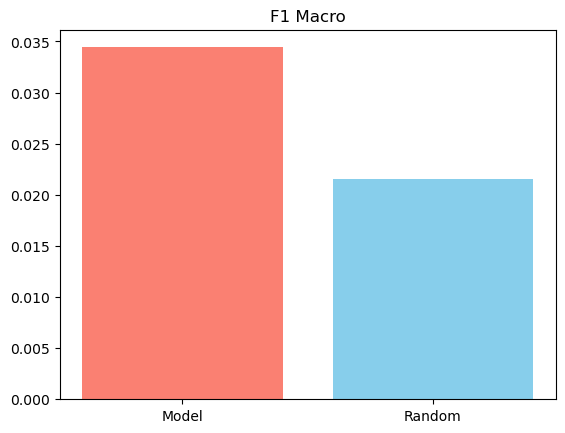

In [11]:
from matplotlib import pyplot as plt

plt.bar(x=(0,1), height=(f1_macro.item(), random_f1_macro.item()), tick_label=("Model", "Random"), color=("salmon", "skyblue"))
plt.title("F1 Macro")
plt.show()

### Class-specific performance

In [12]:
import numpy as np

def plot_class_specific_scores(scores, random_scores, metric_name, labels, sort=True):

    num_classes = len(labels)

    # If sorting is requested, reorder the bars based on the criteria.
    if sort:
        order = torch.argsort(scores).flip(dims=[0])
    else:
        order = torch.arange(len(scores))

    # Reorder the arrays along the class dimension (axis=1) and update the summary statistics
    scores = scores[order]
    random_scores = random_scores[order]
    labels = [labels[i] for i in order]
    # Positions of the groups on the x-axis
    x = np.arange(num_classes)

    # Width of each bar
    width = 0.35

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(25, 12))

    # Plot Random scores bars
    bars1 = ax.bar(x - width/2, random_scores, width,
                label='Random', capsize=5, color='skyblue', edgecolor='black')

    # Plot Actual score bars
    bars2 = ax.bar(x + width/2, scores, width,
                label='Model', capsize=5, color='salmon', edgecolor='black')

    # Add labels and title
    ax.set_xlabel('Phonemes', fontsize=16)
    ax.set_ylabel(metric_name, fontsize=16)
    ax.set_title(metric_name + " for each Phoneme", fontsize=20)

    # Set x-axis tick labels
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, fontsize=16)

    # Add legend
    ax.legend(fontsize=14)

    # Add grid for better readability
    ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

    # Adjust layout to prevent clipping of tick-labels
    plt.tight_layout()

    # Display the plot
    plt.show()

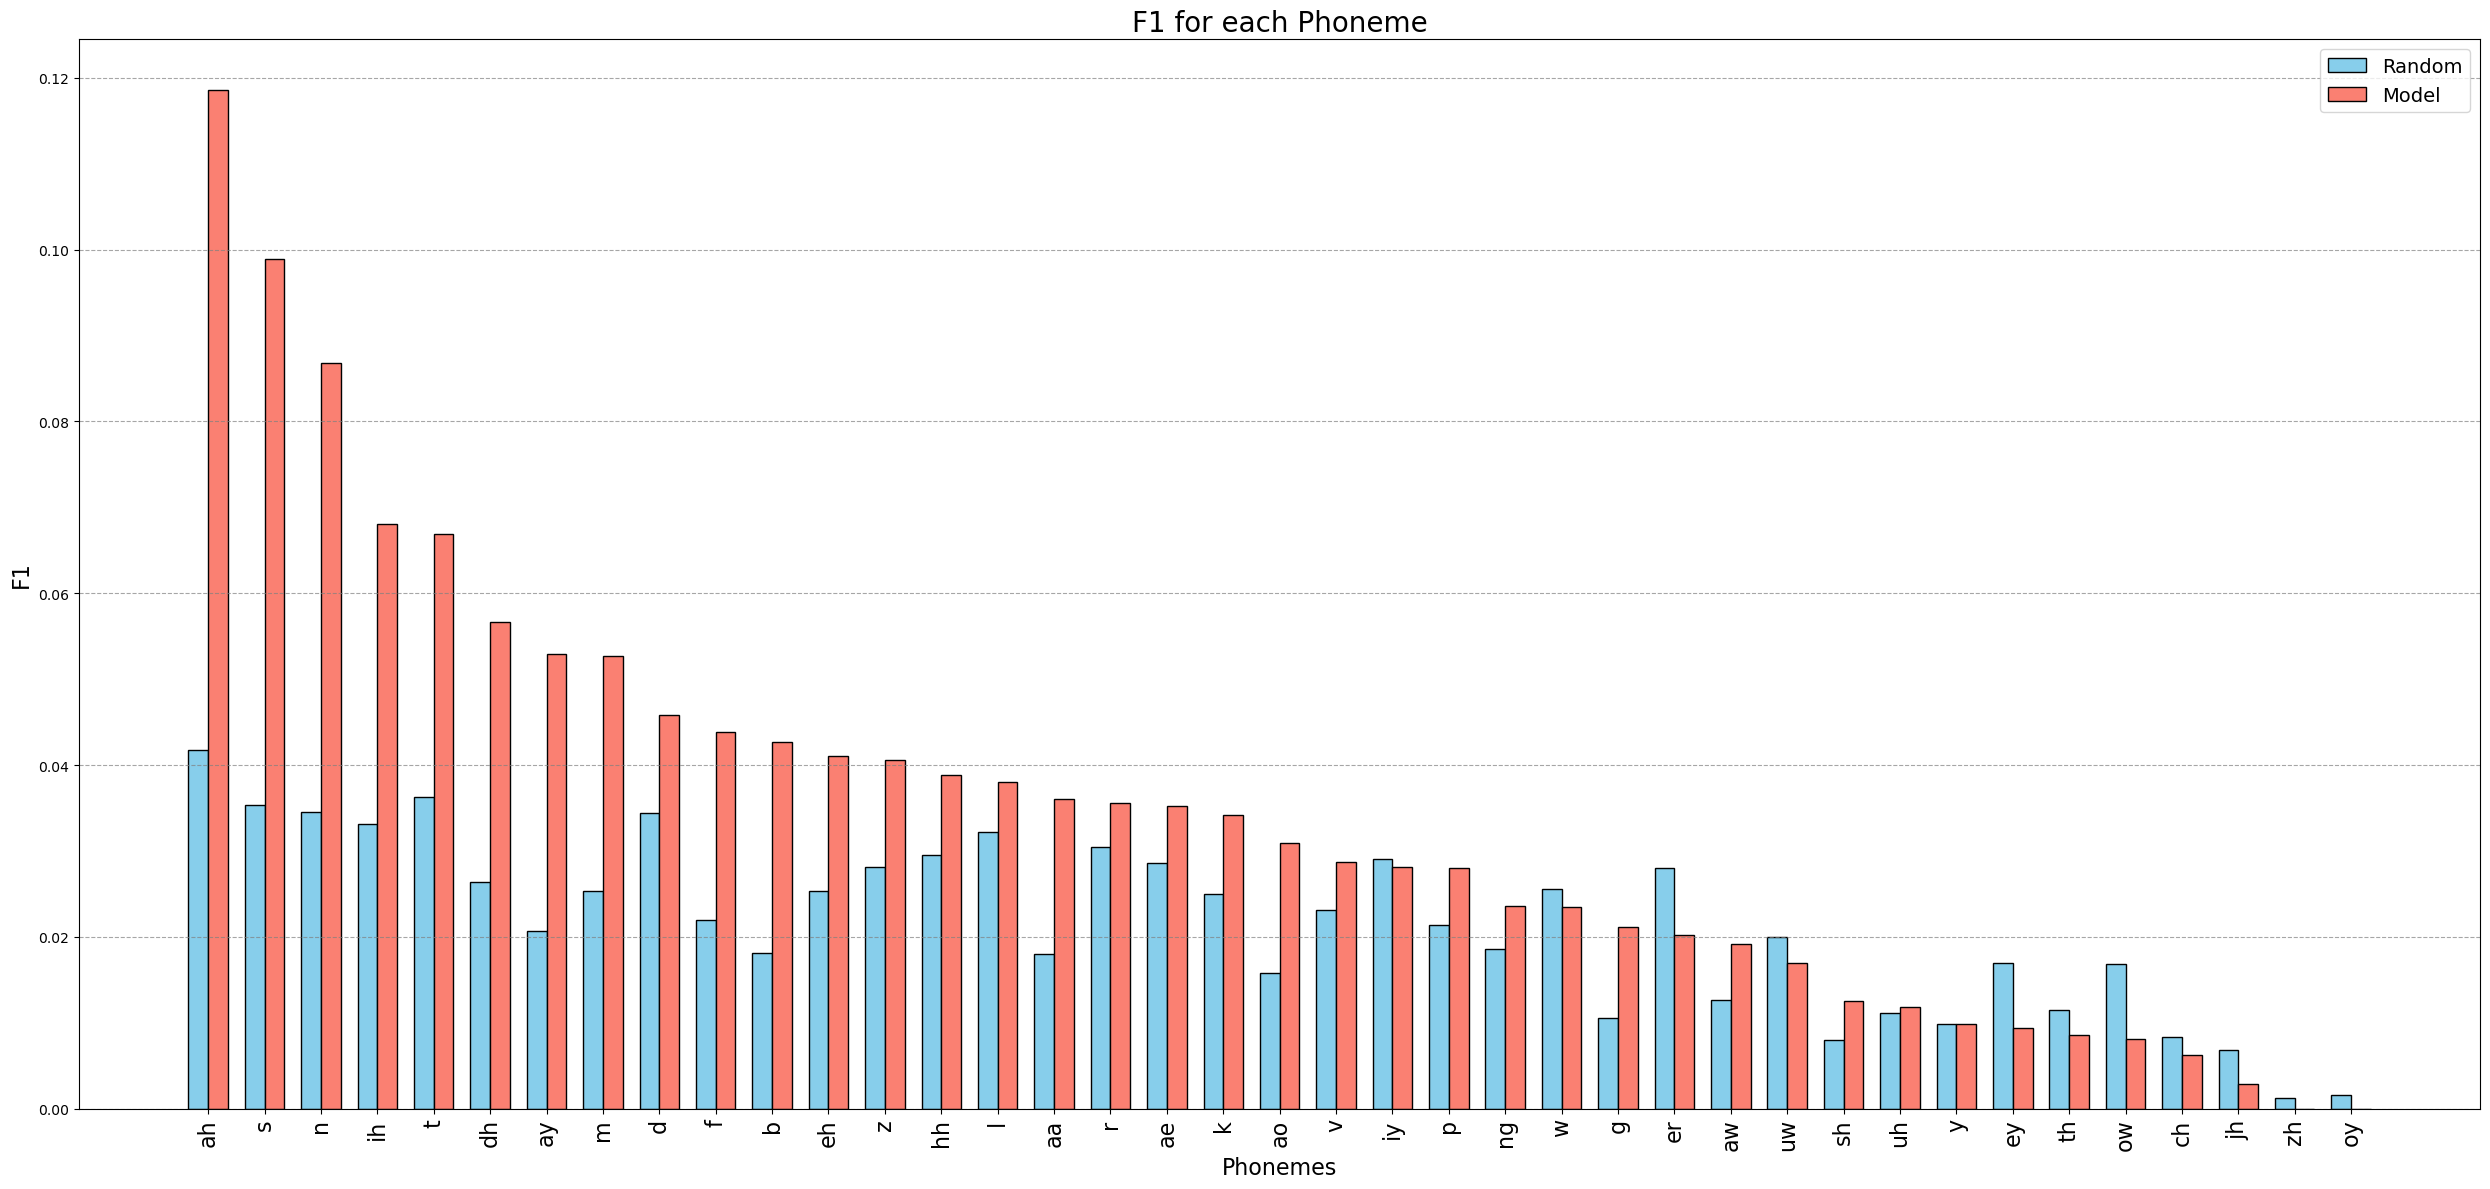

In [13]:
plot_class_specific_scores(scores=f1_by_class, random_scores=random_f1_by_class, metric_name="F1", labels=test_data.labels_sorted)

0.01770020510498221
0.04024406546386579


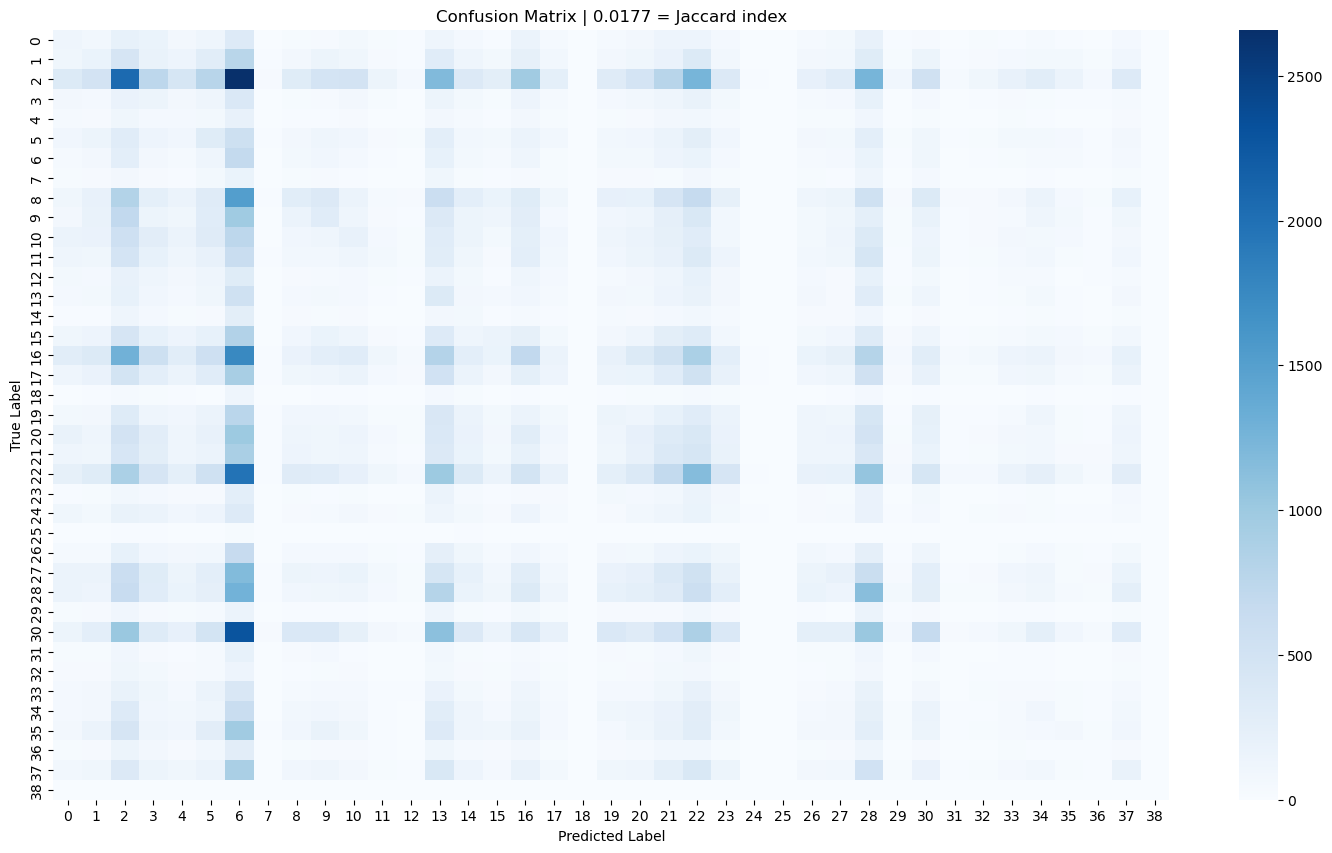

In [14]:
from sklearn.metrics import confusion_matrix, jaccard_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_preds, labels=np.arange(0,39))
iou = jaccard_score(y_true, y_preds, labels=np.arange(0,39), average="macro")
bal_acc = balanced_accuracy_score(y_true, y_preds)
print(iou)
print(bal_acc)

plt.figure(figsize=(18, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix | {np.round(iou,4)} = Jaccard index')
plt.show()